In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos la visual para que los gráficos salgan más claros en el notebook
plt.style.use('ggplot')
print('¡Librerías cargadas correctamente para el análisis exploratorio!')

¡Librerías cargadas correctamente para el análisis exploratorio!


In [3]:
# Cargamos el archivo CSV crudo de la capa Bronze de la Procuraduría
ruta_archivo = "../data/bronze/procuraduria_raw.csv"

df = pd.read_csv(ruta_archivo)

# Mostramos las primeras 5 filas para conocer las columnas y datos originales
print("Vista previa de los datos crudos:")
df.head()

Vista previa de los datos crudos:


,numero_siri,tipo_inhabilidad,calidad_persona,tipo_identificacion,nombre_tipo_identificacion,numero_identificacion,primer_apellido,segundo_apellido,primer_nombre,segundo_nombre,...,duracion_anos,duracion_mes,duracion_dias,providencia,autoridad,fecha_efectos_juridicos,numero_proceso,entidad_sancionado,entidad_departamento,entidad_municipio
0,100011730,DISCIPLINARIO,MIEMBRO DE LA FUERZA PÚBLICA,1,CÉDULA DE CIUDADANÍA,7534386,BOTINA,OLIVEROS,GABRIEL,ANTONIO,...,NaN,NaN,NaN,PRIMERA,COMANDANTE POLICIA METROPOLITANA - CALI (VALLE...,22/04/2005,121-2003,FUERZAS PUBLICAS,BOGOTA DC,BOGOTA DC
1,100014031,DISCIPLINARIO,MIEMBRO DE LA FUERZA PÚBLICA,1,CÉDULA DE CIUDADANÍA,13493450,HERNANDEZ,NI/O,NELSON,ESTEBAN,...,NaN,NaN,NaN,PRIMERA,COMANDANTE DEPARTAMENTO DE POLICIA DE NORTE DE...,21/04/2005,065-2005,FUERZAS PUBLICAS,BOGOTA DC,BOGOTA DC
2,100015504,DISCIPLINARIO,MIEMBRO DE LA FUERZA PÚBLICA,1,CÉDULA DE CIUDADANÍA,72054494,MEZA,SUMALABE,LENIN,ENRIQUE,...,NaN,NaN,NaN,PRIMERA,COMANDANTE DEPARTAMENTO DE POLICIA DE ATLANTIC...,26/05/2005,144 05,FUERZAS PUBLICAS,BOGOTA DC,BOGOTA DC
3,100032482,DISCIPLINARIO,SERVIDOR PÚBLICO,1,CÉDULA DE CIUDADANÍA,10180536,BERNAL,PATI/O,NELSON,NaN,...,NaN,NaN,NaN,PRIMERA,JEFE OFICINA DE CONTROL INTERNO DISCIPLINARIO,17/10/2006,164-2006,ALCALDIA MAYOR DE BOGOTA D.C.,BOGOTA DC,BOGOTA DC
4,100032482,DISCIPLINARIO,SERVIDOR PÚBLICO,1,CÉDULA DE CIUDADANÍA,10180536,BERNAL,PATI/O,NELSON,NaN,...,20.0,NaN,NaN,PRIMERA,JEFE OFICINA DE CONTROL INTERNO DISCIPLINARIO,17/10/2006,164-2006,ALCALDIA MAYOR DE BOGOTA D.C.,BOGOTA DC,BOGOTA DC


In [4]:
# Revisamos cuántas filas y columnas tiene nuestro dataset
print(f"Total de filas (registros): {df.shape[0]}")
print(f"Total de columnas (variables): {df.shape[1]}")

Total de filas (registros): 1000
Total de columnas (variables): 24


In [5]:
# Verificamos los nombres de las columnas y qué tipo de dato tienen
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   numero_siri                 1000 non-null   int64  
 1   tipo_inhabilidad            1000 non-null   str    
 2   calidad_persona             1000 non-null   str    
 3   tipo_identificacion         1000 non-null   int64  
 4   nombre_tipo_identificacion  1000 non-null   str    
 5   numero_identificacion       1000 non-null   int64  
 6   primer_apellido             1000 non-null   str    
 7   segundo_apellido            951 non-null    str    
 8   primer_nombre               1000 non-null   str    
 9   segundo_nombre              742 non-null    str    
 10  cargo                       1000 non-null   str    
 11  lugar_hechos_departamento   934 non-null    str    
 12  lugar_hechos_municipio      934 non-null    str    
 13  sanciones                   1000 non-null   s

In [6]:
# Estamos detectamos cuántos datos vacíos (nulos) tiene cada columna
nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().mean() * 100).round(2)

# Unimos todo en un pequeño DataFrame resumen para verlo ordenado
resumen_nulos = pd.DataFrame({
    'Cantidad de Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos
})

# Filtramos solo las columnas que tienen algún valor nulo
resumen_nulos_filtrado = resumen_nulos[resumen_nulos['Cantidad de Nulos'] > 0]

print("Resumen de valores nulos encontrados en los datos limpios:")
display(resumen_nulos_filtrado)

Resumen de valores nulos encontrados en los datos limpios:


,Cantidad de Nulos,Porcentaje (%)
segundo_apellido,49,4.9
segundo_nombre,258,25.8
lugar_hechos_departamento,66,6.6
lugar_hechos_municipio,66,6.6
duracion_anos,462,46.2
duracion_mes,998,99.8
duracion_dias,1000,100.0


In [7]:
# Estadísticas descriptivas de las columnas numéricas o de conteo
df.describe(include='all')

,numero_siri,tipo_inhabilidad,calidad_persona,tipo_identificacion,nombre_tipo_identificacion,numero_identificacion,primer_apellido,segundo_apellido,primer_nombre,segundo_nombre,...,duracion_anos,duracion_mes,duracion_dias,providencia,autoridad,fecha_efectos_juridicos,numero_proceso,entidad_sancionado,entidad_departamento,entidad_municipio
count,1.000000e+03,1000,1000,1000.0,1000,1.000000e+03,1000,951,1000,742,...,538.000000,2.0,0.0,1000,1000,1000,1000,1000,1000,1000
unique,NaN,1,2,NaN,1,NaN,239,243,181,125,...,NaN,NaN,NaN,4,221,235,279,117,28,56
top,NaN,DISCIPLINARIO,SERVIDOR PÚBLICO,NaN,CÉDULA DE CIUDADANÍA,NaN,RODRIGUEZ,SANCHEZ,LUIS,ALFONSO,...,NaN,NaN,NaN,PRIMERA,JEFE OFICINA DE CONTROL INTERNO DISCIPLINARIO,15/12/2009,008-98537-2004,FUERZAS PUBLICAS,BOGOTA DC,BOGOTA DC
freq,NaN,1000,566,NaN,1000,NaN,18,22,60,36,...,NaN,NaN,NaN,665,128,48,48,434,710,710
mean,1.000644e+08,NaN,NaN,1.0,NaN,7.668300e+07,NaN,NaN,NaN,NaN,...,19.172862,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.564277e+04,NaN,NaN,0.0,NaN,1.819223e+08,NaN,NaN,NaN,NaN,...,1.677390,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000117e+08,NaN,NaN,1.0,NaN,2.759720e+05,NaN,NaN,NaN,NaN,...,5.000000,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.000529e+08,NaN,NaN,1.0,NaN,1.375023e+07,NaN,NaN,NaN,NaN,...,20.000000,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.000673e+08,NaN,NaN,1.0,NaN,3.765154e+07,NaN,NaN,NaN,NaN,...,20.000000,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000774e+08,NaN,NaN,1.0,NaN,8.036939e+07,NaN,NaN,NaN,NaN,...,20.000000,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


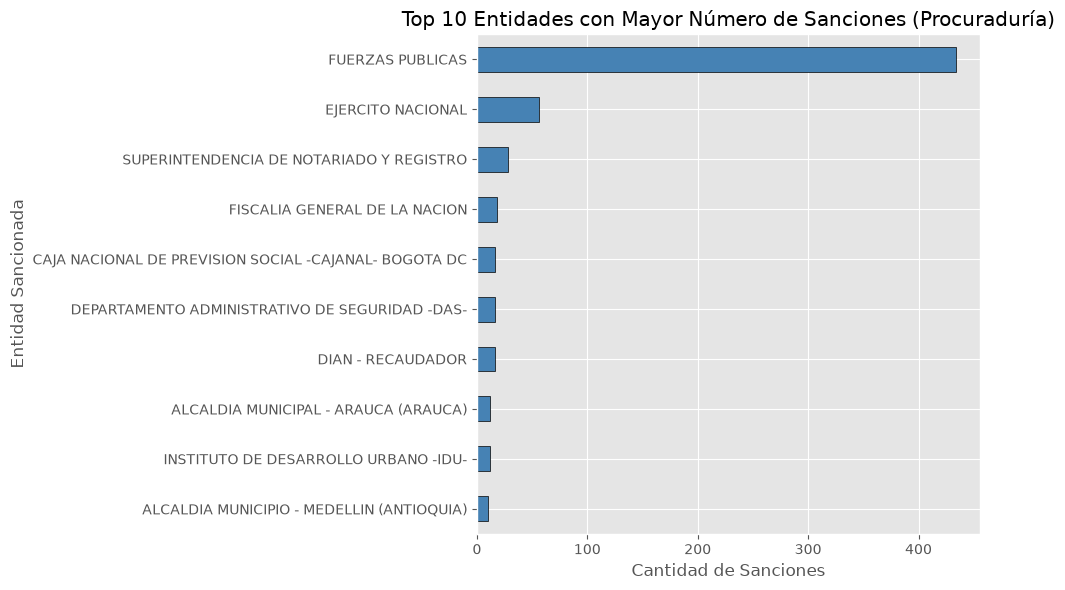

In [8]:
# Vamos a ver gráficamente cuáles son las 10 entidades que más aparecen en este lote de datos
plt.figure(figsize=(10, 6))
top_entidades = df['entidad_sancionado'].value_counts().head(10)

top_entidades.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 Entidades con Mayor Número de Sanciones (Procuraduría)')
plt.xlabel('Cantidad de Sanciones')
plt.ylabel('Entidad Sancionada')
plt.gca().invert_yaxis() # Para que la entidad con más sanciones quede arriba
plt.tight_layout()
plt.show()